# Direct Fire Intensity Prediction (Single-Step Regression)
This notebook trains a predictive model solely on instances where a **fire actually occurred**.

Unlike two-stage models, we skip predicting fire occurrence here and assume we are explicitly modeling the intensity (FRP - Fire Radiative Power) of verified fire events.

### Objectives:
1. Drop all non-fire rows from the dataset before splitting.
2. Train a fast LightGBM regression model on fire events.
3. Evaluate the model strictly on unseen fire events.
4. Visualize Feature Importance and save the model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from lightgbm import LGBMRegressor

%matplotlib inline

## 1. Data Filtering & Preparation
We load the data, immediately drop any rows where `occured == 0`, drop the `occured` column completely, and apply a log transformation to the right-skewed `frp` variable.

In [ ]:
# Load the dataset
df = pd.read_csv('final_dataset.csv')

# EXPLICIT FILTER: Keep only rows where a fire occurred
fire_only_df = df[df['occured'] == 1.0].copy()

# Drop the 'occured' column as it has no variance now (all are 1.0)
fire_only_df = fire_only_df.drop(columns=['occured'])

# Separate Features (X) and Target (y)
# We apply a log1p transformation to frp to handle extreme skewness in fire intensity
X = fire_only_df.drop(columns=['frp'])
y = np.log1p(fire_only_df['frp'])

# Train-Test Split (Only on fire data!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Original dataset shape: {df.shape}")
print(f"Fire-only dataset shape: {fire_only_df.shape}")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Original dataset shape: (118858, 17)
Fire-only dataset shape: (59452, 16)
Training set shape: (47561, 15)
Testing set shape: (11891, 15)


## 2. Model Training
We will use a highly optimized `LGBMRegressor`.

In [ ]:
# Initialize and train the model
reg_model = LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=50,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

reg_model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 3. Evaluation & Insights
We evaluate strictly on the testing subset of the **fire-only** data. We also need to reverse the `log1p` transformation to get real-world errors.

R-squared (R2): 0.0466
Mean Absolute Error (MAE): 17.24


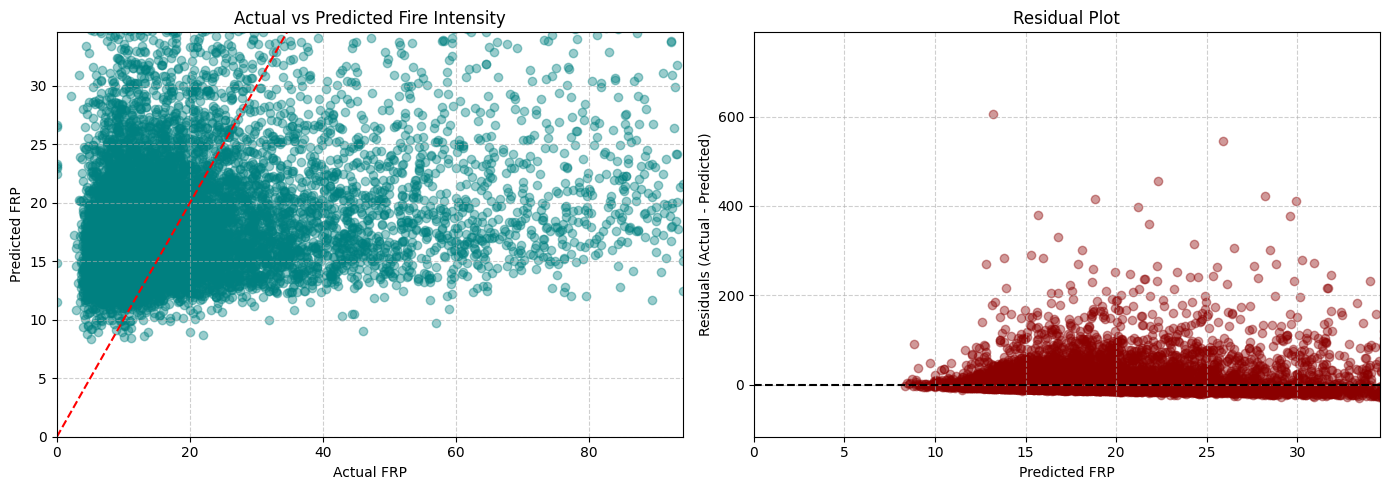

In [ ]:
# Predict on the fire-only test set
log_preds = reg_model.predict(X_test)

# Reverse log transformation (expm1 is the inverse of log1p)
y_test_real = np.expm1(y_test)
preds_real = np.expm1(log_preds)

# Metrics
r2 = r2_score(y_test_real, preds_real)
mae = mean_absolute_error(y_test_real, preds_real)

print(f"R-squared (R2): {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test_real, preds_real, alpha=0.4, color='teal')
axes[0].plot([0, max(y_test_real)], [0, max(y_test_real)], 'r--') # 1:1 Reference line
axes[0].set_xlabel('Actual FRP')
axes[0].set_ylabel('Predicted FRP')
axes[0].set_title('Actual vs Predicted Fire Intensity')
axes[0].set_xlim(0, np.percentile(y_test_real, 95)) # Cap at 95th percentile to hide extreme outliers
axes[0].set_ylim(0, np.percentile(preds_real, 95))
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Residuals
residuals = y_test_real - preds_real
axes[1].scatter(preds_real, residuals, alpha=0.4, color='darkred')
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_xlabel('Predicted FRP')
axes[1].set_ylabel('Residuals (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].set_xlim(0, np.percentile(preds_real, 95))
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Feature Importance
What factors drive the intensity of a fire once it has already started?

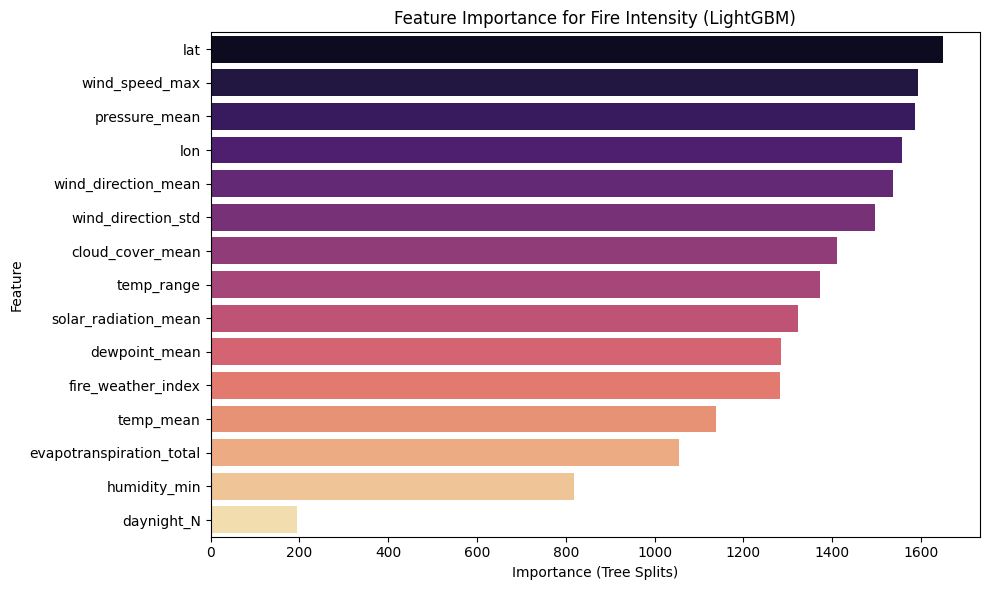

In [ ]:
importance = reg_model.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({'Feature': features, 'Importance': importance})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')
plt.title('Feature Importance for Fire Intensity (LightGBM)')
plt.xlabel('Importance (Tree Splits)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 5. Save Model
Export the regression model for downstream systems.

In [ ]:
joblib.dump(reg_model, 'direct_fire_intensity_lgbm.pkl')
print("Model saved successfully as 'direct_fire_intensity_lgbm.pkl'")

Model saved successfully as 'direct_fire_intensity_lgbm.pkl'
